# Run simulations and access obtained simulation data

## Run simulations

...

## Access obtained simulation data

### Folder structure

Each simulation is created with a master seed.

```bash
ROOT = master seed and simulation name
        ├── experiment.json
        ├── target_values.npy
        ├── target_parameters.csv
        ├── external_current.npy
        └── simulation_1/
            ├── inputs/
            ├── outputs/
            └── ...
```

Example:

```bash
1001_oscillations/
    experiment.json
    target_values.npy
    target_parameters.csv
    external_current.npy
    simulation_1/
    simulation_2/
    ...
```


The simulations come with a .json file called ``experiment.json``. Below we create an instance that retrieves info about the experiment. Now we have predefined what we can loop trough for analysis, and all paths.

In [2]:
from pathlib import Path
from config import Config

# Load the simulation
base_path = Path("simulations/1003_sequences")
oscillations = Config.from_file(base_path)

# Access specific simulation info
print(f"Name: {oscillations.name}")
print(f"Simulation numbers: {oscillations.sim_numbers}")
print(f"vreset values: {oscillations.vresets}")
print(f"pqif numbers: {oscillations.pqif_numbers}")
print(f"Seed numbers: {oscillations.seed_numbers}")

Name: 1003_sequences
Simulation numbers: [1, 2, 3, 4]
vreset values: [-8.5, -12.3, -17, -22]
pqif numbers: [0, 0.25, 0.5, 0.75, 1]
Seed numbers: range(0, 2)


In [3]:
oscillations.metadata  # this shows all of the above, but the lines above can be used for specifics

{'name': '1003_sequences',
 'master_seed': 1003,
 'seed_rule': 'MASTER_SEED + seed + 1',
 'shared_target_current_seed': 1003,
 'network': {'N': 200, 'p': 0.3, 'gsyn': 0.5, 'alpha': 0.25},
 'dynamics': {'dt': 0.1, 'itmax': 1000, 'sigman': 1, 'ts': 5, 'b': 0.2},
 'stimulus': {'itstim': 200, 'current_amplitude': 5},
 'training': {'nloop': 16, 'nloop_train': 10, 'ftrain': 1},
 'target': {'type': 'sequences',
  'amp0': 4,
  'sg_index': 0.15,
  'omegagauss': 0.2},
 'conditions': {'pqif_values': [0, 0.25, 0.5, 0.75, 1], 'n_seeds': 2},
 'simulations': [{'sim': 1, 'vt': 0, 'vreset': -8.5},
  {'sim': 2, 'vt': 0, 'vreset': -12.3},
  {'sim': 3, 'vt': 0, 'vreset': -17},
  {'sim': 4, 'vt': 0, 'vreset': -22}]}

In [10]:
# Get vreset and simulation dependence
sim = oscillations.get_sim(2)
print(sim.sim)
print(sim.vreset)
print(sim.gain)  # At the moment gain is none because this is not automated, so we need to associate gain values. Should automate this later by compting it from the F-I curve fitting automatically from vreset values
print(sim.vt)

2
-12.3
None
0


In [4]:
oscillations.target_dynamics

'sequences'

In [5]:
oscillations.target

{'type': 'sequences', 'amp0': 4, 'sg_index': 0.15, 'omegagauss': 0.2}

In [6]:
oscillations.training["nloop_train"]

10

In [8]:
# Extract paths from instance
base_path = oscillations.path("base")

target_path = oscillations.path("target")

target_parameters_path = oscillations.path(
    "target_parameters"
)

external_current_path = oscillations.path(
    "external_current"
)

# Simulation-specific paths that require a simulation number (SimParam obejct can be passed directly)

simparam_object = oscillations.get_sim(2)

simulation_path = oscillations.path(
    "simulation",
    sim=simparam_object,
)

input_path = oscillations.path(
    "inputs",
    sim=simparam_object,
)

output_path = oscillations.path(
    "outputs",
    sim=simparam_object,
)

connectivity_path = oscillations.path(
    "connectivity",
    sim=simparam_object,
)

currents_path = oscillations.path(
    "currents",
    sim=simparam_object,
)

nspikes_path = oscillations.path(
    "nspikes",
    sim=simparam_object,
)


In [ ]:
# Example looping
# use this loop to loop through everything
for params in oscillations.iter_params():

    sim = params["sim"]
    pqif = params["pqif"]
    seed = params["seed"]

    print(f"Simulation: {sim.sim}")
    print(f"vreset: {sim.vreset}")
    print(f"pqif: {params['pqif']}")
    print(f"seed: {params['seed']}")

    output_dir = oscillations.path(
        "outputs",
        sim=sim,
    )

    filename = (
        f"simulation_{sim.sim}_outputs_"
        f"pqif_{pqif}_iloop_11_seed_{seed}.npy"
    )

    file_path = output_dir / filename

    # data = np.load(file_path)


# Loop through only selected variables (here we pass the dimensions we want to loop through)
# oscillations.iter_params("sim", "pqif") means: for every simulation, for every pqif..
for params in oscillations.iter_params("sim"):

    sim = params["sim"]

    print(
        sim.sim,
        sim.vreset,
    )

# Simulation * pqif
for params in oscillations.iter_params(
    "sim",
    "pqif",
):

    sim = params["sim"]
    pqif = params["pqif"]

    print(
        sim.sim,
        sim.vreset,
        pqif,
    )



# Example
idx = simparam_object.sim  # simulation number
data = "connectivity"
# file = f"simulation_{idx}_{data}_pqif_{pqif}_iloop_11_seed_{seed}.npy"
print(connectivity_path)

How to load

```python
inputs = np.load(path_inputs)
outputs = np.load(path_outputs)
nspikes = np.load(path_nspikes)
to load, use: w = np.load(path_w_seed)

# Add neuron headers to input

inputs = np.load(path)
inputs_df = pd.DataFrame(
    inputs,
    columns=[f"neuron_{i}" for i in range(inputs.shape[1])]
)
```
Data included:

```Large numerical data
    connectivity matrices       .npy
    inputs                      .npy
    outputs                     .npy
    nspikes                     .npy
    target values               .npy
    external current            .npy

Metadata / analysis tables
    parameters                  .csv
    target parameters           .csv
    neuron assignments          .csv
    motif results               .csv
    weight evolution            .csv
    selected currents           .csv```

NumPy data is stored with float64, which means 8 bytes per number and double precision. Some of it could be stored as float32

Reproducibility-seeds are stored in parameter file

Loading modt, modw:

```python
dw = np.load(filename_dw)

modt = dw["modt"]
modw = dw["modw"]
```


### Import colormap for figures

# Evaluate training

In [ ]:
import numpy as np

def evaluate_training():
    """
    Compute Pearson correlation between target activity and network activity.
    single_seed: Choose a random seed within the seed range.
    all_seeds: Average correlation across seeds.
    """
    pass


input_path = oscillations.path("inputs", sim=simparam_object)  # Base path for input
target_path = oscillations.path("target")  # Target is shared across all
target = np.load(target_path)

input_seedlevel = f"simulation_{sim_idx}_inputs_pqif_{pqif}_iloop_{loop_idx}_seed_{seed}"
inputs = np.load(input_path / input_seedlevel)


for params in oscillations.iter_params("sim"):

    sim = params["sim"]

    print(
        sim.sim,
        sim.vreset,
    )

# Simulation * pqif
for params in oscillations.iter_params(
    "sim",
    "pqif",
):

    sim = params["sim"]
    pqif = params["pqif"]

    print(
        sim.sim,
        sim.vreset,
        pqif,
    )


Used seed 0
Used simulation 1


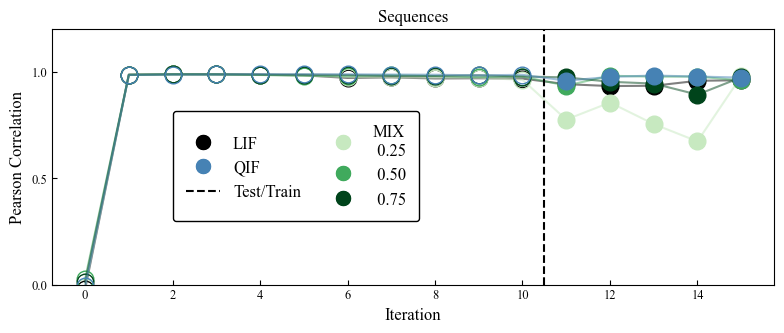

In [ ]:


# Imports
import matplotlib as plt
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from brokenaxes import brokenaxes
import os
import random

########## Initializations ##########


# Simulation variables
simulation_number = [i for i in range(9,13)]  # or 9, 13 if sequences
vr_number = [-8.5, -12.3, -17, -22]
slope = [14.44, 10.68, 8.65, 7.18]
pqif_values = [0, 0.25, 0.5, 0.75, 1]
names = ["LIF", f"MIX\n 0.25", " 0.50", " 0.75", "QIF"]
seed_number = [i for i in range(0, 5)]  # If only one seed, set to (0, 1)

# Parameters used during oscillation
N = 200
pq = 0
idx = 1
itmax = 1000
itstim = 200 
nloop = 16

yticks_top = [0.80, 1]
yticks_bottom = [0, 0.2]


# Create figure
fig, ax = plt.subplots(
    figsize=(8,3.5)
    )
figname = f"sequences_correlation"
figure_folder = 'V2/final_figures_thesis'
from pathlib import Path
# base_path = Path(r"J:\ordinary_simulations")  # ordinary simulations
base_path = Path("simulations\oscillations")
base_path.mkdir(parents=True, exist_ok=True)

# seed = random.randint(1)  # random seed
seed = 0
print(f"Used seed {seed}")

for pq, nombre in zip(pqif_values, names):
    # Formatting
    color = color_map_pqif[pq]
    cc = np.zeros(nloop)  # Initialize array
    cc_std = np.zeros(nloop)  # Initialize array for std

    for iloop in range(nloop):
        # Load target
        target_csv = pd.read_csv(base_path / 'target_values.csv')
        targets = target_csv.values

        file = base_path / f'simulation_{idx}/inputs/simulation_{idx}_inputs_pqif_{pq}_iloop_{iloop}_seed_{seed}.csv'  # load input
        # simulation_1\inputs\simulation_1_inputs_pqif_0_iloop_0_seed_0.csv
        df = pd.read_csv(file, header=None).values
        ci = np.zeros(N)
        for i in range(N):
            rout_i = df[:, i]
            if np.var(targets[itstim:, i]) > 0 and np.var(rout_i[itstim:]) > 0:  # If variance above 0
                ci[i] = pearsonr(targets[itstim:, i], rout_i[itstim:])[0]  # Pearson R of target and input
        cc[iloop] = np.mean(ci)
        cc_std[iloop] = np.std(ci)

    # Plot curves and markers ON BOTH AXES
    ax.plot(np.arange(nloop), cc, color=color, alpha=0.5)
    ax.plot(np.arange(1, 11), cc[1:11], 'o', markersize=12, color=color, markerfacecolor='none')
    ax.plot(np.arange(11, 16), cc[11:], 'o', markersize=12, color=color, markerfacecolor=color)
    ax.plot(0, cc[0], 'o', color=color, markersize=12, markerfacecolor='none')



# Normal y axis
ax.set_ylim(0, 1.2)
# ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticks([0, 0.5, 1])

# Labels and scales
ax.set_title('Sequences')
ax.axvline(10.5, color='black', linestyle="--")
ax.set_xlabel('Iteration')
ax.set_ylabel("Pearson Correlation")



# Optional: custom legend
legend_elements = []
labels = []

names = ["LIF", "QIF", f"MIX\n 0.25", " 0.50", " 0.75"]
pqif_values = [0, 1, 0.25, 0.50, 0.75]

for nombre, pq in zip(names, pqif_values):
    color = color_map_pqif[pq]
    train_marker = Line2D([0], [0], marker='o', color=color, markerfacecolor='none',
                          markersize=10, linestyle='None')
    test_marker = Line2D([0], [0], marker='o', color=color, markerfacecolor=color,
                         markersize=10, linestyle='None')
    legend_elements.append((train_marker, test_marker))
    labels.append(f"{nombre}")

vertical_line = Line2D([0], [0], color='black', linestyle='--')
# legend_elements.append(vertical_line)
# labels.append(f"Test/Train")
legend_elements.insert(2, vertical_line)
labels.insert(2, f"Test/Train")


# ax_bottom.legend(legend_elements, labels, handler_map={tuple: HandlerTuple()}, loc='lower right')
ax.legend(
    legend_elements,
    labels,
    handler_map={tuple: HandlerTuple()},
    ncol=2,                             # number of columns
    loc='center',                       # anchor point
    bbox_to_anchor=(0.38, 0.5),          # center of axes or figure depending on next line
    bbox_transform=fig.transFigure,     # figure coordinates
    frameon=True,                       # rectangular legend box
    edgecolor='black',
    framealpha=1.0,
    # borderpad=1.2,
    borderpad=0.8,
    columnspacing=1.5,
    handletextpad=0.8
)

print(f"Used simulation {idx}")
plt.tight_layout()
# full_path = os.path.join(figure_folder, figname)
# plt.savefig(full_path, format="svg")
plt.show()

# Old notebook

In [1]:
from config import SimParam, Config  # Classes
from pathlib import Path
import sys
import matplotlib.pyplot as plt

all_pqif = [0, 0.25, 0.5, 0.75, 1]
seeds = range(10)

# Each simulation is associated with a vreset value and a gain value
simparam = [
    SimParam(1, -8.5, 14.56),
    SimParam(2, -12.3, 10.76),
    SimParam(3, -17.0, 8.21),
    SimParam(4, -22.0, 7.33),
]



oscillations = Config(
    name="oscillations",
    sims=simparam,
    pqif_numbers=all_pqif,
    seed_numbers=seeds,
    base_path="simulations/1000_oscillations",
    optional_params=None,
    parameter_folder="simulations/1000_oscillations/target_parameters.csv",
)

print(f"Loaded configuration:\n{'-'*10}\n{repr(oscillations)}\n{'-'*10}")

# Get and load color map (handles if it is in another folder)
cwd = Path.cwd()
while not (cwd / "color_map.py").exists():
    cwd = cwd.parent
sys.path.insert(0, str(cwd))
from color_map import make_color_map

vresets = oscillations.vresets
gains = oscillations.gains
pqif_vector = oscillations.pqif_numbers
color_map_vrest = make_color_map(vresets, plt.cm.Reds)  # Reds for vrest
color_map_gains = make_color_map(gains, plt.cm.Reds)
color_map_pqif = make_color_map(pqif_vector[1:-1], plt.cm.Greens)  # Greens for pqif
color_map_pqif[pqif_vector[0]] = 'black'
color_map_pqif[pqif_vector[-1]] = 'steelblue'

print(f"Created colormaps for vrest {vresets}, gains {gains}, pqif {pqif_vector}")

# Load matplotlib style (handles if in another folder)
from pathlib import Path
cwd = Path.cwd()
while not (cwd / "plos.mplstyle").exists():
    cwd = cwd.parent

style_path = Path(cwd / 'plos.mplstyle')
plt.style.use(style_path)

print(f"Imported matplotlib style from path {style_path}")

# base_path = Path(f"J:/baseline_simulations")
# print(f"Base path: {base_path}")

Loaded configuration:
----------
Config name: oscillations
  pqif: [0, 0.25, 0.5, 0.75, 1]
  simulations: 1 : (vreset=-8.5, gain=14.56), 2 : (vreset=-12.3, gain=10.76), 3 : (vreset=-17.0, gain=8.21), 4 : (vreset=-22.0, gain=7.33)
  across 10 seeds
  Optional parameters:
[]
  Base path: simulations\1000_oscillations
----------
Created colormaps for vrest [-8.5, -12.3, -17.0, -22.0], gains [14.56, 10.76, 8.21, 7.33], pqif [0, 0.25, 0.5, 0.75, 1]
Imported matplotlib style from path c:\Users\snrambo\Projects\NEVR3901\HeterogenousRNN\HeterogeneousRNNs\structured_connectivity\plos.mplstyle


Access files:

In [2]:
from pathlib import Path

base_path = oscillations.base_path

def get_path(name, sim, parent=None):
    if parent:
        parent_dir = base_path / f"{parent}"
        simulation_dir = parent_dir / f"simulation_{sim}"
    else:
        simulation_dir = base_path / f"simulation_{sim}"

    paths = {
        "target": base_path / "target_values",
        "simulation": simulation_dir,
        "connectivity": simulation_dir / "connectivity_matrix",
        "outputs": simulation_dir / "outputs",
        "inputs": simulation_dir / "inputs",
    }

    return paths[name]

path = get_path("inputs", 1)
print(path)

# Example connectivity matrix:

idx = 2
pqif = 0.5
seed = 3
data = "connectivity"

file = f"simulation_{idx}_{data}_pqif_{pqif}_iloop_11_seed_{seed}.npy"

path = get_path(data, idx)

w = path / file
print(w)


simulations\1000_oscillations\simulation_1\inputs
simulations\1000_oscillations\simulation_2\connectivity_matrix\simulation_2_connectivity_pqif_0.5_iloop_11_seed_3.npy


How to loop through using the instances of objects:

Evaluation of training

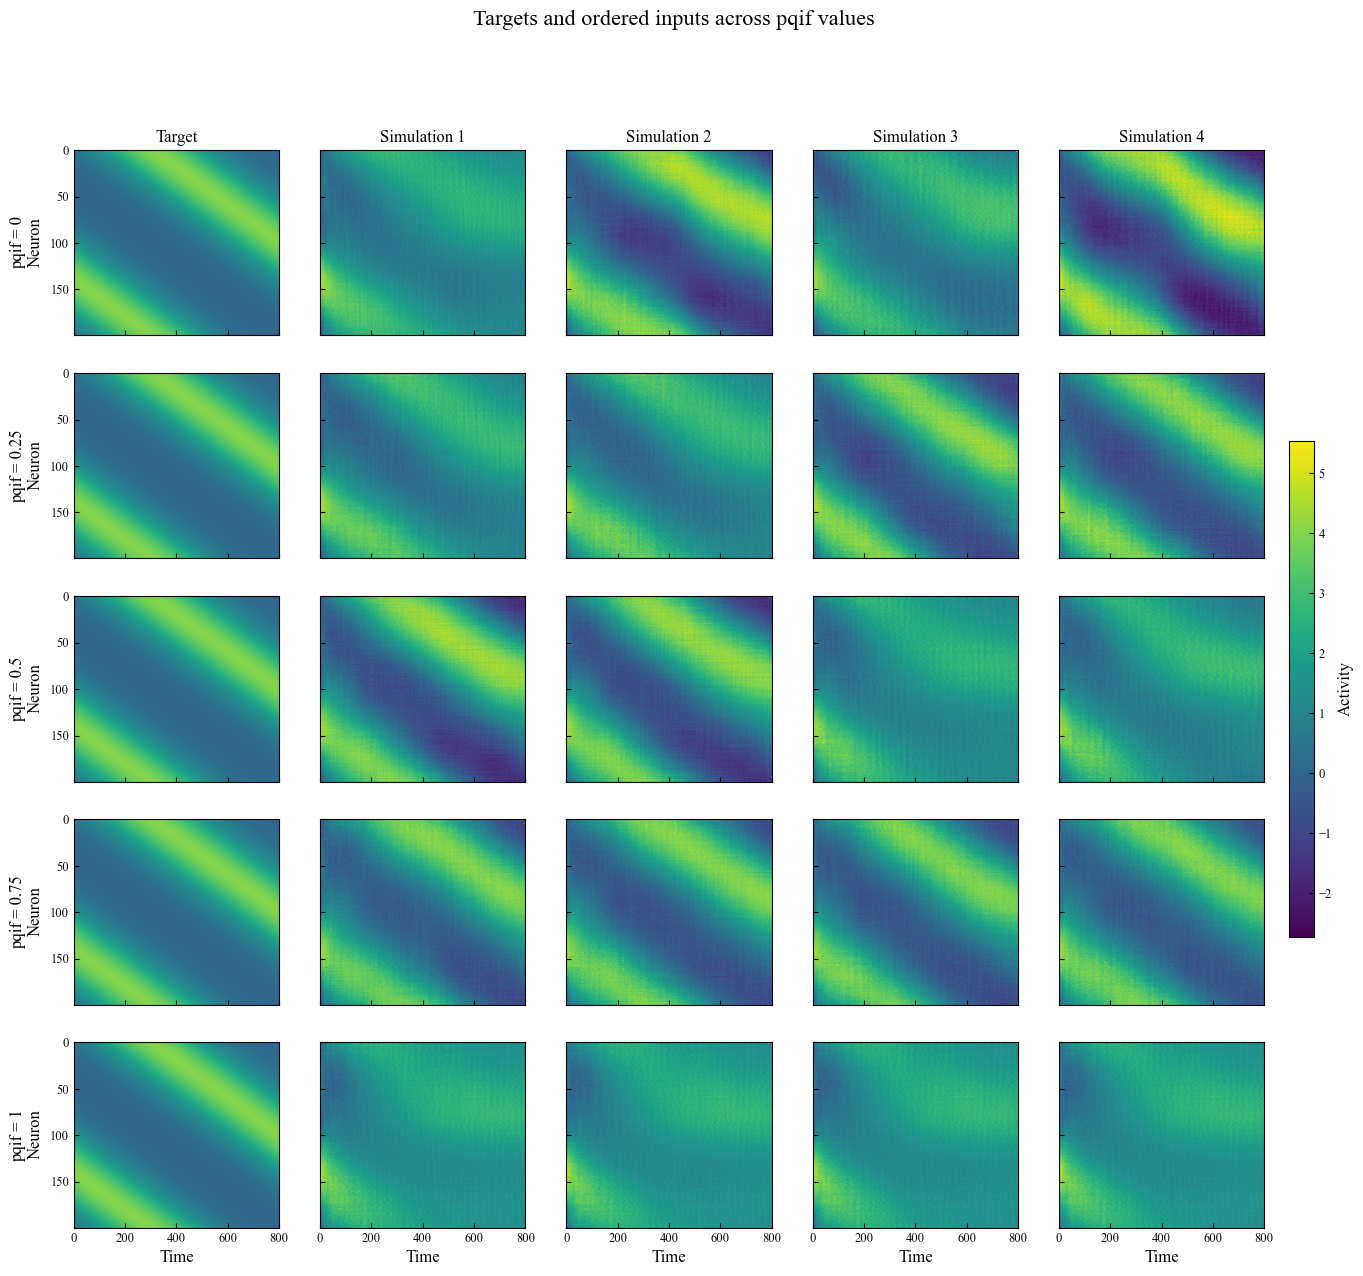

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# --- Parameters
iloop = 14
pqif_values = [0, 0.25, 0.5, 0.75, 1]
simulations = [i for i in range(1, 5)]

# --- Paths
base_path = Path("simulations") / "sequences"
FIGURES_DIR = base_path / "figures" / "presentation"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Store all data here
plot_data = {}
all_values = []


# Get sequence ordering
target_parameters = pd.read_csv(
    base_path / "target_parameters.csv"
)
sequence_position = target_parameters["sequence_position"].to_numpy()

inv_order = np.argsort(sequence_position)


# Load target
target = pd.read_csv(
    base_path / "target_values.csv"
).values

# Remove transient and order neurons by sequence position
target_rest = np.nan_to_num(target[200:, :])
targets_ordered = target_rest.T[inv_order, :]

plot_data = {}
all_values = []

for pqif in pqif_values:
    plot_data[pqif] = {}

    # Same target for every pqif
    plot_data[pqif]["Target"] = targets_ordered
    all_values.append(targets_ordered)

    for idx in simulations:
        sim_path = base_path / f"simulation_{idx}"

        # Load input
        inputs = pd.read_csv(
            sim_path / "inputs"
            / f"simulation_{idx}_inputs_pqif_{pqif}_iloop_{iloop}_seed_0.csv",
            header=None
        ).values

        # Remove transient
        inputs_rest = np.nan_to_num(inputs[200:, :])

        # Order neurons according to their sequence position
        inputs_ordered = inputs_rest.T[inv_order, :]

        plot_data[pqif][f"Simulation {idx}"] = inputs_ordered
        all_values.append(inputs_ordered)

# Shared color scale for all plots
vmin = min(arr.min() for arr in all_values)
vmax = max(arr.max() for arr in all_values)

# --- Plot
column_titles = ["Target"] + [f"Simulation {idx}" for idx in simulations]

fig, axes = plt.subplots(
    nrows=len(pqif_values),
    ncols=len(column_titles),
    figsize=(16, 14),
    sharex=True,
    sharey=True
)

for row, pqif in enumerate(pqif_values):
    for col, title in enumerate(column_titles):
        ax = axes[row, col]

        im = ax.imshow(
            plot_data[pqif][title],
            cmap="viridis",
            aspect="auto",
            vmin=vmin,
            vmax=vmax
        )

        ax.set_xlim(0, 800)

        if row == 0:
            ax.set_title(title)

        if col == 0:
            ax.set_ylabel(f"pqif = {pqif}\nNeuron")

        if row == len(pqif_values) - 1:
            ax.set_xlabel("Time")

# Shared colorbar
fig.colorbar(
    im,
    ax=axes,
    orientation="vertical",
    label="Activity",
    fraction=0.02,
    pad=0.02
)

fig.suptitle("Targets and ordered inputs across pqif values", fontsize=16)
# fig.tight_layout()

# fig_path = FIGURES_DIR / "targets_and_inputs_all_pqif.svg"
# plt.savefig(fig_path, dpi=300)
# print(f"Figure saved to {fig_path}")

plt.show()